# U3.5 實作：步數變少時，要改 coupling 還是改 solver？

U3.2 與 U3.3 改 coupling，希望 learned ODE trajectory 更接近等速直線；U3.4 保持原本的 training，改用 Heun 與 adaptive step size，更準地積分同一個 velocity field。這份 notebook 把這些不同的方法實作在 U3.2 中的經典 toy example (from Rectified Flow)，最後用一張 2×3 的圖並排比較：

| 圖 | training 用的 coupling | solver | NFE |
| --- | --- | --- | ---: |
| (a) | 投影片上的交叉配對（一般 FM） | Euler | 100 |
| (b) | 同 (a) | Euler | 4 |
| (c) | Reflow 一次 | Euler | 4 |
| (d) | Minibatch OT | Euler | 4 |
| (e) | 同 (a) | Heun | 4 |
| (f) | 同 (a) | Heun ＋ adaptive step size | 由 tolerance 決定 |

(a)、(b) 是對照組；(c)、(d) 只換 coupling，(e)、(f) 只換 solver。

| 時間 | 內容 |
| --- | --- |
| 0–5 min | 交叉 toy：先猜左上的點會走到哪裡 |
| 5–12 min | 共用的 `FlowMatching` class；訓練一般 FM，比較 100 與 4 NFE |
| 12–20 min | 改 coupling：Reflow 一次、minibatch OT |
| 20–27 min | 改 solver：Heun、adaptive step size |
| 27–30 min | 2×3 總表 |

In [1]:
# 需要 torch、numpy、scipy、matplotlib（Colab 都已內建）
import math, time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

START_TIME = time.time()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

SIGMA = 0.28          # 每一群 Gaussian 的標準差（和投影片相同）
TRAIN_STEPS = 5000    # 三個模型都訓練這麼多步
BATCH_SIZE = 256
OT_BATCH_SIZE = 128   # minibatch OT 每一步要解一次 B×B 的 assignment，batch 小一點比較快
LEARNING_RATE = 2e-3
MANY_NFE = 100        # 圖 (a)：步數夠多的參考
FEW_NFE = 4           # 圖 (b)–(e)：只能詢問 4 次 velocity
N_EVAL = 1000         # 評估用的樣本數

def set_seed(seed=0):
    np.random.seed(seed)
    torch.manual_seed(seed)

print("device:", DEVICE)

device: cpu


## 1. toy example

起點與終點各有上下兩個 Gaussian clusters，每群各佔 $\tfrac12$：

$$
\begin{aligned}
p_0&=\tfrac12\,\mathcal N\big((-2,1),\sigma^2I\big)+\tfrac12\,\mathcal N\big((-2,-1),\sigma^2I\big),\\
p_1&=\tfrac12\,\mathcal N\big((2,1),\sigma^2I\big)+\tfrac12\,\mathcal N\big((2,-1),\sigma^2I\big),
\qquad \sigma=0.28.
\end{aligned}
$$

Training 時故意把左上配到右下、左下配到右上。令 $S\in\{-1,+1\}$ 各以 $\tfrac12$ 機率取樣，

$$
X_0=(-2,S)+\sigma\varepsilon_0,\qquad
X_1=(2,-S)+\sigma\varepsilon_1,\qquad
\varepsilon_0,\varepsilon_1\overset{\mathrm{iid}}{\sim}\mathcal N(0,I).
$$

同一對端點沿直線 $X_t=(1-t)X_0+tX_1$ 移動，所以兩束 reference paths 在原點附近交叉；到了 $t=\tfrac12$，兩束的中點都落在原點。

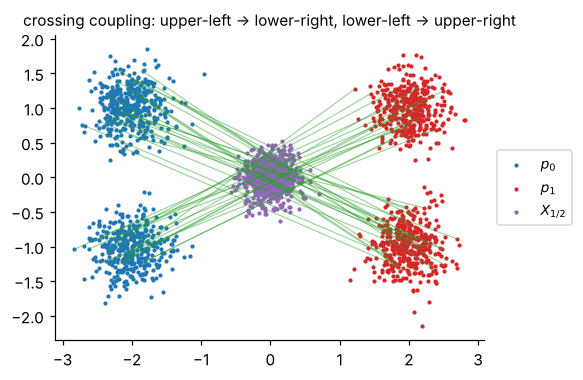

In [2]:
def sample_clusters(n, x_center, sign=None):
    # x 座標在 x_center；sign = +1 是上面那群（y≈1），-1 是下面那群（y≈-1）
    if sign is None:
        sign = torch.randint(0, 2, (n,), device=DEVICE) * 2.0 - 1.0
    center = torch.stack([torch.full_like(sign, x_center), sign], dim=1)
    return center + SIGMA * torch.randn(n, 2, device=DEVICE)

def sample_p0(n):
    return sample_clusters(n, -2.0)

def sample_p1(n):
    return sample_clusters(n, 2.0)

def sample_crossing_pairs(n):
    # 投影片的配對規則：左上 → 右下、左下 → 右上
    sign = torch.randint(0, 2, (n,), device=DEVICE) * 2.0 - 1.0
    return sample_clusters(n, -2.0, sign), sample_clusters(n, 2.0, -sign)

set_seed(0)
x0, x1 = (x.cpu().numpy() for x in sample_crossing_pairs(800))
fig, ax = plt.subplots(figsize=(6.4, 3.6))
for a, b in zip(x0[:40], x1[:40]):
    ax.plot([a[0], b[0]], [a[1], b[1]], color="tab:green", lw=0.7, alpha=0.5)
ax.scatter(*x0.T, s=3, color="tab:blue", label="$p_0$")
ax.scatter(*x1.T, s=3, color="tab:red", label="$p_1$")
ax.scatter(*(0.5 * (x0 + x1)).T, s=3, color="tab:purple", label="$X_{1/2}$")
ax.set_aspect("equal")
ax.set_title("crossing coupling: upper-left -> lower-right, lower-left -> upper-right", fontsize=10)
ax.legend(loc="center right", bbox_to_anchor=(1.22, 0.5), fontsize=9)
plt.show()

**先寫下你的猜測：** 用這組配對訓練 Flow Matching，再從左上那群出發解 ODE。這些點最後會落在右下（照著 training 時的配對走），還是右上？

## 2. 簡化 FlowMatching : training 只看配對，sampling 只看 velocity
 
下一格是 U2 lab 的 `FlowMatching` class 的簡化版。`fit` 只認得一個 `get_batch()`：它回傳一批 $(x_0,x_1)$，class 就用 linear path 畫直線，對 $X_1-X_0$ 做 regression：

$$
\mathcal L(\theta)=\mathbb E_{t,\,(X_0,X_1)\sim\pi}\Big[\big\|v_\theta(X_t,t)-(X_1-X_0)\big\|^2\Big].
$$

**coupling $\pi$ 全部寫在 `get_batch` 裡。** 下面三個模型的差別，只有傳進 `fit` 的那一個函數：

| 模型 | `get_batch` 回傳的 $(x_0,x_1)$ |
| --- | --- |
| 一般 FM | 投影片的交叉配對 |
| Reflow | 起點，與它沿著一般 FM 的 ODE 走到的終點 |
| Minibatch OT | 從 $p_0$、$p_1$ 各抽一批，再在 batch 內重新配對 |

Sampling 這邊，`integrate` 用 Euler 或 Heun 從 $t=0$ 積到 $t=1$。**它吃的是 NFE，不是步數**：Euler 每一步詢問一次 velocity，Heun 每一步詢問兩次，所以 `nfe=4` 時 Euler 走 4 步、Heun 走 2 步。回傳的 `path` 保留每一步的位置，畫圖時就看得到每一步走到哪裡。

In [3]:
def time_features(t, n_freq=6):
    # (B,) -> (B, 1 + 2*n_freq)：讓 MLP 比較容易表示「t≈0.5 附近方向很快改變」
    t = t.reshape(-1, 1)
    k = (2 ** torch.arange(n_freq, device=t.device, dtype=t.dtype)) * math.pi
    return torch.cat([t, torch.sin(t * k), torch.cos(t * k)], dim=1)


class VelocityMLP(nn.Module):
    def __init__(self, hidden=128, n_freq=6):
        super().__init__()
        self.n_freq = n_freq
        self.net = nn.Sequential(
            nn.Linear(2 + 1 + 2 * n_freq, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, time_features(t, self.n_freq)], dim=1))


class FlowMatching:
    def __init__(self, seed=0):
        set_seed(seed)
        self.net = VelocityMLP().to(DEVICE)

    def loss(self, x0, x1):
        t = torch.rand(len(x0), device=DEVICE)
        xt = (1 - t[:, None]) * x0 + t[:, None] * x1          # linear path
        return ((self.net(xt, t) - (x1 - x0)) ** 2).mean()

    def fit(self, get_batch, steps=TRAIN_STEPS, name="model"):
        optimizer = torch.optim.Adam(self.net.parameters(), lr=LEARNING_RATE)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=steps)
        start, history = time.time(), []
        for step in range(1, steps + 1):
            loss = self.loss(*get_batch())
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            scheduler.step()
            history.append(loss.item())
            if step % (steps // 5) == 0:
                print(f"[{name}] step {step:5d}/{steps}: loss = {np.mean(history[-500:]):.4f}")
        self.final_loss = np.mean(history[-500:])
        print(f"[{name}] {time.time() - start:.0f} s")

    @torch.no_grad()
    def velocity(self, x, t):
        # t 是一個數字：這一批點都在同一個時間詢問 velocity
        return self.net(x, torch.full((len(x),), float(t), device=x.device))


@torch.no_grad()
def integrate(flow, x0, nfe, solver="euler"):
    n_steps = nfe if solver == "euler" else nfe // 2          # Heun 每一步要 2 NFE
    h = 1.0 / n_steps
    x, path = x0, [x0]
    for k in range(n_steps):
        t = k * h
        v0 = flow.velocity(x, t)
        if solver == "euler":
            x = x + h * v0
        else:
            x_pred = x + h * v0                                     # predictor：先用 Euler 試走
            x = x + 0.5 * h * (v0 + flow.velocity(x_pred, t + h))   # corrector：平均兩端的 velocity
        path.append(x)
    return torch.stack(path)                                    # shape: (步數 + 1, n, 2)

### 怎麼判斷終點分布對不對？

用 U3.1 的 $W_2$：把生成的點和同樣多的真資料一對一配起來，讓平均搬運距離平方最小，再開根號。這一步用的 `linear_sum_assignment`，和等一下 minibatch OT 用的是同一個。

兩組真資料互比，$W_2$ 也不會是 0；這個**地板**先量出來，後面的數字都和它比。評估時上下兩群各取一半：設計上兩群隔得很遠，如果某一次剛好多抽了 2% 的上面那群，$W_2$ 有可能就會因此多出約 0.2，蓋過我們本來想要看的差別。算是我們根據原分布去特地選的。

下一格只是評估與畫圖的小工具，直接執行即可。

In [4]:
def w2(x, y):
    cost = torch.cdist(x, y).square().cpu().numpy()
    rows, cols = linear_sum_assignment(cost)
    return float(np.sqrt(cost[rows, cols].mean()))

set_seed(2026)
half = torch.tensor([1.0, -1.0], device=DEVICE).repeat_interleave(N_EVAL // 2)
X0_EVAL = sample_clusters(N_EVAL, -2.0, half)       # 前一半在左上、後一半在左下
TARGET = sample_clusters(N_EVAL, 2.0, half)
FLOOR = w2(sample_clusters(N_EVAL, 2.0, half), TARGET)
print(f"W2 地板（兩組真資料互比）= {FLOOR:.3f}")

TRACKED = torch.cat([torch.arange(12), N_EVAL // 2 + torch.arange(12)])   # 畫軌跡的點：上下各 12 個
RESULTS = {}                                                              # (a)–(f) 都存在這裡，最後一起畫

def clean(ax):
    ax.set_xlim(-3.2, 3.2)
    ax.set_ylim(-2.1, 2.1)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("0.8")

def show(ax, title, path, nfe):
    path = path.cpu().numpy()
    ax.scatter(*TARGET.cpu().numpy().T, s=4, color="0.85", zorder=0)
    ax.scatter(*path[0].T, s=4, color="tab:blue", alpha=0.25, zorder=1)
    marker = "o" if len(path) <= 40 else None                             # 步數少時，標出每一步走到的位置
    for i in TRACKED:
        ax.plot(path[:, i, 0], path[:, i, 1], color="0.2", lw=0.8, alpha=0.75,
                marker=marker, ms=2.5, zorder=2)
    ax.scatter(*path[-1].T, s=4, color="tab:red", alpha=0.6, zorder=3)
    ax.set_title(f"{title}\nNFE = {nfe},  $W_2$ = {w2(torch.as_tensor(path[-1]), TARGET.cpu()):.3f}", fontsize=10)
    clean(ax)

W2 地板（兩組真資料互比）= 0.075


## 3. 一般 FM：步數夠多，和只剩 4 NFE

照投影片的配對訓練，`get_batch` 就是 `sample_crossing_pairs`：

In [5]:
fm = FlowMatching(seed=0)
fm.fit(lambda: sample_crossing_pairs(BATCH_SIZE), name="一般 FM")

[一般 FM] step  1000/5000: loss = 0.5422


[一般 FM] step  2000/5000: loss = 0.5370


[一般 FM] step  3000/5000: loss = 0.5197


[一般 FM] step  4000/5000: loss = 0.5251


[一般 FM] step  5000/5000: loss = 0.5226
[一般 FM] 9 s


Loss 停在 0.5 附近，不會降到 0：同一個 $(x,t)$ 附近會出現彼此衝突的 reference velocities，L2 regression 只能學到它們的 conditional mean，剩下的部分就是 U3.2 的 $V(\pi)$。兩束在中間重疊的那一段，衝突最大。

固定同一批起點，分別用 100 NFE 與 4 NFE 的 Euler 積分。藍點是起點、紅點是生成的終點、淺灰是真的 $p_1$；黑線是 24 個點的 trajectories；步數少時，圓點標出每一步走到的位置。

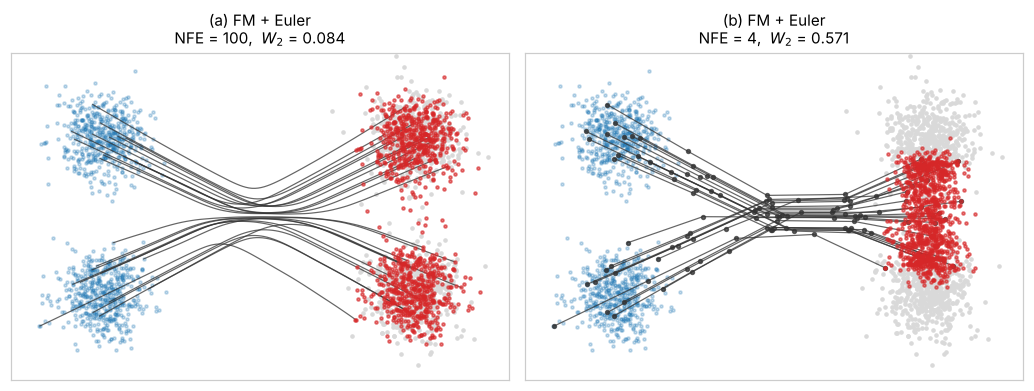

100 NFE：從左上出發的點，最後落在上半部的比例 = 0.99


In [6]:
RESULTS["a"] = ("(a) FM + Euler", integrate(fm, X0_EVAL, MANY_NFE), MANY_NFE)
RESULTS["b"] = ("(b) FM + Euler", integrate(fm, X0_EVAL, FEW_NFE), FEW_NFE)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
for ax, key in zip(axes, "ab"):
    show(ax, *RESULTS[key])
plt.tight_layout()
plt.show()

end = RESULTS["a"][1][-1]
print(f"100 NFE：從左上出發的點，最後落在上半部的比例 = {(end[:N_EVAL // 2, 1] > 0).float().mean():.2f}")

**100 NFE：** 左上的點走到右上，沒有照 training 的配對走到右下。在同一個 $(x,t)$，learned velocity 只能給一個方向，所以 ODE trajectories 不會交叉：兩束點先一起被擠向原點，過了 $t\approx\tfrac12$ 再上下分開。終點分布仍然接近 $p_1$，但每一條 trajectory 都在中間轉了一個彎。

**4 NFE：** Euler 每一步跨 $h=\tfrac14$。前兩步照著起點的方向直直走到原點附近；第三步在 $t=\tfrac12$ 詢問 velocity，那裡兩束完全重疊，velocity 幾乎只剩向右的分量；只剩最後一步可以往上下分開，一半以上的終點因此停在兩群之間。U3.1 的 bound $h\int_0^1\|a_t(x_t)\|\,\mathrm dt$ 說的就是這件事：acceleration 集中在中間那一段，$h$ 太大就整段跨過去了。

那接著就得問：只有 4 NFE 時，要把 trajectory 本身拉直（改 coupling），還是把這 4 次詢問用得更好（改 solver）？下面依序試兩種。

## 4. 改 coupling（一）：Reflow 一次

Reflow 的配對從 (a) 的 ODE 來：抽一批起點，沿著一般 FM 的 ODE 走到終點，把每個起點和它實際抵達的終點存成一對。產生配對時用 100 NFE 的 Heun，讓 solver error 不要混進新的 training data。接著建立一個**新的** model，用這批 pairs 再做一次 Flow Matching。

In [7]:
@torch.no_grad()
def make_reflow_pairs(flow, n=20000, nfe=100):
    x0 = sample_p0(n)
    x1 = integrate(flow, x0, nfe, solver="heun")[-1]
    return x0, x1

REFLOW_X0, REFLOW_X1 = make_reflow_pairs(fm)

def reflow_batch():
    idx = torch.randint(0, len(REFLOW_X0), (BATCH_SIZE,), device=DEVICE)
    return REFLOW_X0[idx], REFLOW_X1[idx]

reflow = FlowMatching(seed=1)
reflow.fit(reflow_batch, name="Reflow")
RESULTS["c"] = ("(c) Reflow + Euler", integrate(reflow, X0_EVAL, FEW_NFE), FEW_NFE)
print(f"(c) W2 = {w2(RESULTS['c'][1][-1], TARGET):.3f}（地板 {FLOOR:.3f}）")

[Reflow] step  1000/5000: loss = 0.0008


[Reflow] step  2000/5000: loss = 0.0007


[Reflow] step  3000/5000: loss = 0.0007


[Reflow] step  4000/5000: loss = 0.0006


[Reflow] step  5000/5000: loss = 0.0006
[Reflow] 9 s
(c) W2 = 0.078（地板 0.075）


## 5. 改 coupling（二）：Minibatch OT

Minibatch OT 不用投影片的配對規則，也不需要先訓練好的模型：每一步從 $p_0$、$p_1$ 各抽一批，在 batch 內解一次 assignment，讓搬運距離平方的總和最小，再照常畫直線。重排只是把同一批終點換個順序，所以兩端的 empirical marginals 不變。

In [8]:
def minibatch_ot_pair(x0, x1):
    cost = torch.cdist(x0, x1).square().cpu().numpy()
    rows, cols = (torch.as_tensor(i, device=x0.device) for i in linear_sum_assignment(cost))
    return x0[rows], x1[cols]

def ot_batch():
    return minibatch_ot_pair(sample_p0(OT_BATCH_SIZE), sample_p1(OT_BATCH_SIZE))

batch_ot = FlowMatching(seed=2)
batch_ot.fit(ot_batch, name="Minibatch OT")
RESULTS["d"] = ("(d) Minibatch OT + Euler", integrate(batch_ot, X0_EVAL, FEW_NFE), FEW_NFE)
print(f"(d) W2 = {w2(RESULTS['d'][1][-1], TARGET):.3f}（地板 {FLOOR:.3f}）")

[Minibatch OT] step  1000/5000: loss = 0.0493


[Minibatch OT] step  2000/5000: loss = 0.0520


[Minibatch OT] step  3000/5000: loss = 0.0462


[Minibatch OT] step  4000/5000: loss = 0.0470


[Minibatch OT] step  5000/5000: loss = 0.0467
[Minibatch OT] 22 s
(d) W2 = 0.079（地板 0.075）


三個模型用同一個 class，path、loss 與 optimizer 都一樣，差別在配對（minibatch OT 為了算得快，batch 用 128）。把三種 coupling 畫出來的 reference paths 並排：

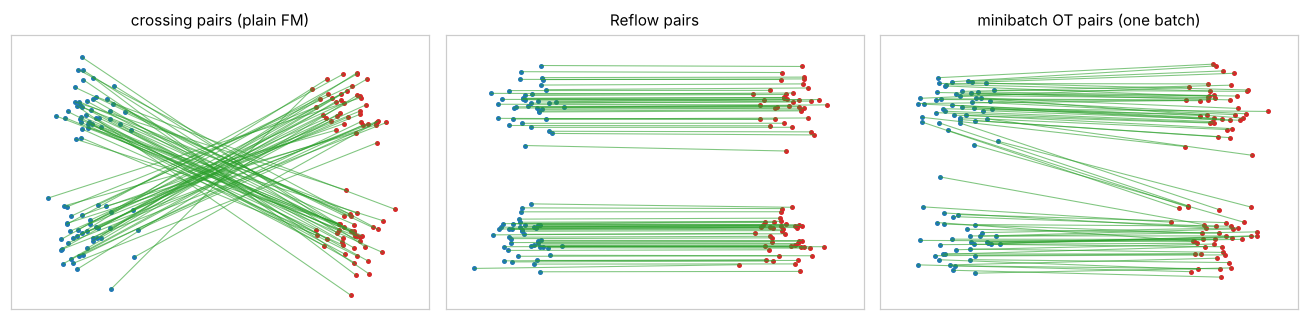

minibatch OT：50 個 batch 平均，上下互換的配對比例 = 0.047
       一般 FM：最後 500 步的平均 loss = 0.5226
      Reflow：最後 500 步的平均 loss = 0.0006
Minibatch OT：最後 500 步的平均 loss = 0.0467


In [9]:
set_seed(3)
couplings = [
    ("crossing pairs (plain FM)", sample_crossing_pairs(OT_BATCH_SIZE)),
    ("Reflow pairs", reflow_batch()),
    ("minibatch OT pairs (one batch)", ot_batch()),
]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, (title, (a, b)) in zip(axes, couplings):
    a, b = a[:80].cpu().numpy(), b[:80].cpu().numpy()
    for p, q in zip(a, b):
        ax.plot([p[0], q[0]], [p[1], q[1]], color="tab:green", lw=0.7, alpha=0.6)
    ax.scatter(*a.T, s=5, color="tab:blue")
    ax.scatter(*b.T, s=5, color="tab:red")
    ax.set_title(title, fontsize=10)
    clean(ax)
plt.tight_layout()
plt.show()

swapped = [((a[:, 1] > 0) != (b[:, 1] > 0)).float().mean().item() for a, b in (ot_batch() for _ in range(50))]
print(f"minibatch OT：50 個 batch 平均，上下互換的配對比例 = {np.mean(swapped):.3f}")
for name, model in [("一般 FM", fm), ("Reflow", reflow), ("Minibatch OT", batch_ot)]:
    print(f"{name:>12s}：最後 500 步的平均 loss = {model.final_loss:.4f}")

Reflow 與 minibatch OT 的 reference paths 幾乎都是水平的：左上配右上、左下配右下，沒有交叉，learned velocity 不必在中間轉彎，Euler 一步跨一大段也不會偏掉。Minibatch OT 還留著少數斜線：一個 batch 裡上下兩群的點數不一定相同，多出來的點只能配到另一側（上面量到約 5% 的配對上下互換）。

最後的 loss 也在說同一件事。模型夠好時，loss 會停在該 coupling 的 $V(\pi)$：一般 FM 的交叉配對留下約 0.5；minibatch OT 留下約 0.05，來自少數斜線，以及同一個起點在不同 batch 會配到不同的終點；Reflow 的 pairs 是確定的，直線又幾乎不交叉，同一個 $(x,t)$ 只對應一個方向，loss 幾乎降到 0。

另外，Reflow 的終點來自 (a) 的 ODE，所以 (a) 的模型誤差也會一起被帶進新的配對（U3.2）。

## 6. 改 solver：Heun 與 adaptive step size

這一節不重新 training，回到一般 FM 的 velocity field，只換積分方法。

**Heun（同樣 4 NFE）：** 每一步先用 Euler 試走到 $\tilde x_{t+h}$，在那裡再詢問一次 velocity，用兩端的平均修正這一步。4 NFE 只夠走 2 步。

**Adaptive step size：** U3.4 說過，Euler predictor 與 Heun corrector 的差 $\|x^{\mathrm H}_{t+h}-\tilde x_{t+h}\|$ 會隨這一段的 velocity 變化一起變大。差距小於 tolerance 就接受這一步、下一步放大 $h$；太大就拒絕、縮小 $h$ 再算。這裡整批點共用同一個步長，所以要求**每一個點**的差距都小於 `tol`。下一步的 $h$ 乘上 $0.9\,(\text{tol}/\text{差距})^{1/2}$（限制在 0.2 到 2 倍之間）：差距大約和 $h^2$ 成正比，所以開根號。被拒絕的嘗試也花了 2 NFE，一樣算進去。

**先猜：** adaptive solver 會把時間節點平均分布，還是集中在某一段？如果集中，會在哪裡？

In [10]:
@torch.no_grad()
def adaptive_heun(flow, x0, tol=0.05, h=0.1):
    x, t, nfe, rejected = x0, 0.0, 0, 0
    path, times = [x0], [0.0]
    while t < 1 - 1e-9:
        h = min(h, 1 - t)
        v0 = flow.velocity(x, t)
        x_pred = x + h * v0                                          # Euler predictor
        x_heun = x + 0.5 * h * (v0 + flow.velocity(x_pred, t + h))   # Heun corrector
        nfe += 2
        err = (x_heun - x_pred).norm(dim=1).max().item() / tol       # 看最差的那一個點
        if err <= 1:                                                 # 接受這一步
            t, x = t + h, x_heun
            path.append(x)
            times.append(t)
        else:                                                        # 拒絕：x、t 不動，縮小 h 重算
            rejected += 1
        h = h * min(2.0, max(0.2, 0.9 / max(err, 1e-12) ** 0.5))
    return torch.stack(path), nfe, times, rejected

RESULTS["e"] = ("(e) FM + Heun", integrate(fm, X0_EVAL, FEW_NFE, solver="heun"), FEW_NFE)
path_f, nfe_f, times_f, rejected_f = adaptive_heun(fm, X0_EVAL, tol=0.05)
RESULTS["f"] = ("(f) FM + adaptive Heun", path_f, nfe_f)

print(f"(e) W2 = {w2(RESULTS['e'][1][-1], TARGET):.3f}")
print(f"(f) W2 = {w2(path_f[-1], TARGET):.3f}，NFE = {nfe_f}（其中 {2 * rejected_f} 次花在被拒絕的嘗試）")
print("(f) 接受的時間節點：", "  ".join(f"{t:.2f}" for t in times_f))

(e) W2 = 0.223
(f) W2 = 0.089，NFE = 38（其中 12 次花在被拒絕的嘗試）
(f) 接受的時間節點： 0.00  0.10  0.20  0.28  0.35  0.42  0.48  0.52  0.56  0.60  0.68  0.78  0.89  1.00


## 7. 2×3 總表

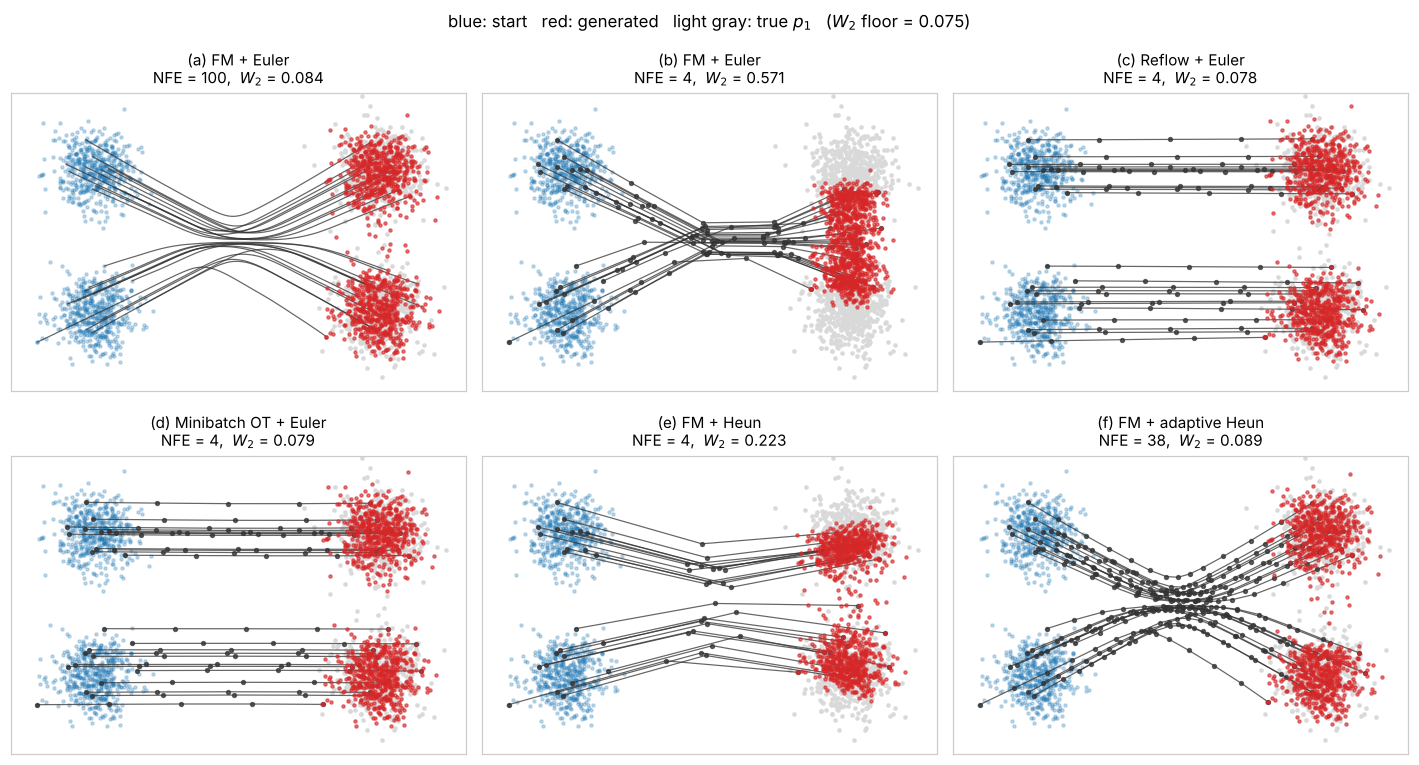

                                  NFE      W2
(a) FM + Euler                    100   0.084
(b) FM + Euler                      4   0.571
(c) Reflow + Euler                  4   0.078
(d) Minibatch OT + Euler            4   0.079
(e) FM + Heun                       4   0.223
(f) FM + adaptive Heun             38   0.089
(f') FM + Heun, uniform steps      38   0.080
floor (true vs true)                    0.075


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.4))
for ax, key in zip(axes.flat, "abcdef"):
    show(ax, *RESULTS[key])
fig.suptitle(f"blue: start   red: generated   light gray: true $p_1$   ($W_2$ floor = {FLOOR:.3f})", fontsize=11)
plt.tight_layout()
fig.savefig("u3_5_results.png", dpi=160, bbox_inches="tight")
plt.show()

uniform = integrate(fm, X0_EVAL, nfe_f, solver="heun")     # 對照：把 (f) 的 NFE 交給均勻步長的 Heun
rows = [(RESULTS[k][0], RESULTS[k][2], w2(RESULTS[k][1][-1], TARGET)) for k in "abcdef"]
rows.append(("(f') FM + Heun, uniform steps", nfe_f, w2(uniform[-1], TARGET)))
print(f"{'':32s}{'NFE':>5s}{'W2':>8s}")
for title, nfe, dist in rows:
    print(f"{title:32s}{nfe:>5d}{dist:>8.3f}")
print(f"{'floor (true vs true)':32s}{'':>5s}{FLOOR:>8.3f}")

## 8. 讀這張圖

1. (b) 和 (e) 都只有 4 NFE。Heun 為什麼比 Euler 好，卻還是比不上 (c)、(d)？

<details><summary>想一想再打開</summary>

Heun 每一步多詢問一次 velocity，看得到這一步裡 velocity 改變了多少，所以修正得比 Euler 好。但它解的仍然是 (a) 的那個 field：trajectory 在 $t\approx\tfrac12$ 附近轉彎，4 NFE 只夠走兩步，每一步跨過半個時間區間，轉彎本身沒有消失。(c)、(d) 改的是 field：trajectory 幾乎是等速直線，Euler 一步就走得準。

</details>

2. (f) 的時間節點集中在哪裡？solver 事先不知道轉彎在哪裡，它怎麼決定在那裡縮小步長？

<details><summary>想一想再打開</summary>

節點集中在 $t=\tfrac12$ 前後，也就是兩束點被擠到原點、再上下分開的那一段；兩端的步長則被放大。Solver 沒有用到「轉彎在 $t=\tfrac12$」這個資訊，是 Euler predictor 與 Heun corrector 的差在那一段變大，步長才被縮小。代價寫在 NFE 上：它花的 NFE 是 (b)–(e) 的好幾倍，其中一部分花在被拒絕的嘗試。

</details>

3. (c) 和 (d) 都只用 4 NFE，而且 $W_2$ 接近地板。兩者的配對各自從哪裡來？各付出了什麼？

<details><summary>想一想再打開</summary>

Reflow 的配對來自 (a) 的 ODE：先訓練一個模型、跑一次 ODE 產生 pairs、再訓練一次，(a) 的模型誤差也會跟著進入新的配對。Minibatch OT 不需要先有模型，但每一步要解一個 $B\times B$ 的 assignment；在這個二維 toy 上很便宜，維度高時，cost matrix 裡的距離彼此差不多，重新配對的效果會變弱（U3.3）。

</details>

### 課後可以再試

- 把 (b) 的 NFE 改成 1 或 3：`p = integrate(fm, X0_EVAL, 3)`，觀察 $W_2$ 有什麼變化。再用 `(p[-1][:N_EVAL // 2, 1] > 0).float().mean()` 看看：從左上出發的點，這次落在哪一群？
- 把 `adaptive_heun` 的 `tol` 調大或調小，記錄 NFE 與 $W_2$ 怎麼一起變。
- 把 `OT_BATCH_SIZE` 改成 16 或 32：上下互換的配對比例、以及 (d) 的結果會怎麼變？
- 用 `reflow` 再產生一組 pairs，做第二次 Reflow。

In [12]:
print(f"total runtime: {(time.time() - START_TIME) / 60:.1f} min")

total runtime: 0.8 min
